# AI Credit Risk Project - Advanced Models

I'm working with advance models to  compares stronger tree-based ensemble models against the baseline models from Notebook 07.

Advanced models in this stage:
- Random Forest
- XGBoost
- LightGBM

The goal is to improve risk ranking and bad-risk detection while keeping the validation/test workflow clean.

## 1. Environment Setup

I loaded libraries, connect to the project source code, and check whether XGBoost and LightGBM are available in the current kernel.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

project_root = Path.cwd().resolve().parents[0]
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from credit_risk_platform.data.german_credit import interim_german_credit_dir
from credit_risk_platform.utils.io import load_csv

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")

print("project_root:", project_root)
print("XGBoost available:", XGBClassifier is not None)
print("LightGBM available:", LGBMClassifier is not None)

project_root: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform
XGBoost available: True
LightGBM available: True


## 2. Load the Standardised Dataset


In [2]:
interim_dir = interim_german_credit_dir(project_root)
df = load_csv(interim_dir / "german_credit_standardized.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 24)


,applicant_id,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate_pct_income,personal_status_sex,...,other_installment_plans,housing,existing_credits_count,job_type,liable_people_count,telephone,foreign_worker,risk_class,risk_label,TARGET
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,A143,A152,2,A173,1,A192,A201,1,good,0
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,A143,A152,1,A173,1,A191,A201,2,bad,1
2,3,A14,12,A34,A46,2096,A61,A74,2,A93,...,A143,A152,1,A172,2,A191,A201,1,good,0
3,4,A11,42,A32,A42,7882,A61,A74,2,A93,...,A143,A153,1,A173,2,A191,A201,1,good,0
4,5,A11,24,A33,A40,4870,A61,A73,3,A93,...,A143,A153,2,A173,2,A191,A201,2,bad,1


## 3. Define Features and Target

Exclude identifiers and target-derived fields from the model feature set.

In [3]:
target_col = "TARGET"
identifier_cols = ["applicant_id"]
target_label_cols = ["risk_class", "risk_label"]
exclude_from_features = identifier_cols + target_label_cols + [target_col]

feature_cols = [col for col in df.columns if col not in exclude_from_features]
X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature count:", len(feature_cols))
display(pd.DataFrame({"feature_cols": pd.Series(feature_cols)}))

Feature count: 20


,feature_cols
0,checking_account_status
1,duration_months
2,credit_history
3,purpose
4,credit_amount
5,savings_account
6,employment_duration
7,installment_rate_pct_income
8,personal_status_sex
9,other_debtors_guarantors


## 4. Recreate Train, Validation, and Test Splits

I used same stratified split so advanced models can be compared fairly with the baseline models.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (700, 20)
Validation: (150, 20)
Test: (150, 20)


## 5. Build Tree-Based Preprocessing

Because this is Tree-based models do not require feature scaling, so this pipeline I use imputation and one-hot encoding only.

In [5]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 7
Categorical features: 13


## 6. Define Advanced Models

Always remember that Random Forest is always available through scikit-learn. XGBoost and LightGBM are included when installed in the active environment.

In [6]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

advanced_models = {
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
}

if XGBClassifier is not None:
    advanced_models["xgboost"] = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

if LGBMClassifier is not None:
    advanced_models["lightgbm"] = LGBMClassifier(
        n_estimators=300,
        max_depth=-1,
        learning_rate=0.05,
        num_leaves=15,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )

advanced_models

{'random_forest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                        n_estimators=300, n_jobs=-1, random_state=42),
 'xgboost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=300,
               n_jobs=-1, num_parallel_tree=None, random_state=42, ...),
 'lightgbm': LGBMClassifier(class_weight='balanced', learning_rate

## 7. Train and Evaluate Advanced Models

I evaluate all models on the validation set first. The test set remains untouched for later final comparison.

In [7]:
def evaluate_classifier(model_name, fitted_pipeline, X_eval, y_eval):
    y_pred = fitted_pipeline.predict(X_eval)
    y_score = fitted_pipeline.predict_proba(X_eval)[:, 1]

    return {
        "model": model_name,
        "accuracy": round(accuracy_score(y_eval, y_pred), 4),
        "balanced_accuracy": round(balanced_accuracy_score(y_eval, y_pred), 4),
        "precision_bad_risk": round(precision_score(y_eval, y_pred, zero_division=0), 4),
        "recall_bad_risk": round(recall_score(y_eval, y_pred, zero_division=0), 4),
        "f1_bad_risk": round(f1_score(y_eval, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_eval, y_score), 4),
        "pr_auc": round(average_precision_score(y_eval, y_score), 4),
    }

fitted_advanced_pipelines = {}
advanced_results = []

for model_name, model in advanced_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    fitted_advanced_pipelines[model_name] = pipeline
    advanced_results.append(evaluate_classifier(model_name, pipeline, X_valid, y_valid))

advanced_results_df = pd.DataFrame(advanced_results).sort_values("roc_auc", ascending=False)
advanced_results_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,roc_auc,pr_auc
0,random_forest,0.7133,0.6937,0.5179,0.6444,0.5743,0.7873,0.6113
1,xgboost,0.7000,0.6778,0.5000,0.6222,0.5545,0.7663,0.5810
2,lightgbm,0.6933,0.6540,0.4902,0.5556,0.5208,0.7393,0.5853


## 8. Compare Against Baseline Results

I'm comparing advanced models against the baseline table from Notebook 07.

In [8]:
baseline_path = project_root / "artifacts" / "tables" / "baseline_model_validation_results.csv"

if baseline_path.exists():
    baseline_results_df = pd.read_csv(baseline_path)
    model_comparison_df = pd.concat([baseline_results_df, advanced_results_df], ignore_index=True)
    model_comparison_df = model_comparison_df.sort_values("roc_auc", ascending=False)
else:
    print("Baseline results not found yet. Showing advanced models only.")
    model_comparison_df = advanced_results_df.copy()

model_comparison_df

,model,accuracy,balanced_accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,roc_auc,pr_auc
3,random_forest,0.7133,0.6937,0.5179,0.6444,0.5743,0.7873,0.6113
0,logistic_regression,0.6867,0.7063,0.4857,0.7556,0.5913,0.7723,0.5911
4,xgboost,0.7000,0.6778,0.5000,0.6222,0.5545,0.7663,0.5810
5,lightgbm,0.6933,0.6540,0.4902,0.5556,0.5208,0.7393,0.5853
1,decision_tree_depth_4,0.6200,0.6524,0.4231,0.7333,0.5366,0.6818,0.4269
2,dummy_most_frequent,0.7000,0.5000,0.0000,0.0000,0.0000,0.5000,0.3000


## 9. Review the Best Advanced Model

Inspect the strongest advanced model using validation metrics and classification output.

In [9]:
best_advanced_model_name = advanced_results_df.iloc[0]["model"]
best_advanced_pipeline = fitted_advanced_pipelines[best_advanced_model_name]

y_valid_pred = best_advanced_pipeline.predict(X_valid)
y_valid_score = best_advanced_pipeline.predict_proba(X_valid)[:, 1]

print("Best advanced model:", best_advanced_model_name)
print(classification_report(y_valid, y_valid_pred, target_names=["good_risk", "bad_risk"]))

Best advanced model: random_forest
              precision    recall  f1-score   support

   good_risk       0.83      0.74      0.78       105
    bad_risk       0.52      0.64      0.57        45

    accuracy                           0.71       150
   macro avg       0.67      0.69      0.68       150
weighted avg       0.74      0.71      0.72       150



In [10]:
report = classification_report(
    y_valid,
    y_valid_pred,
    target_names=["good_risk", "bad_risk"],
    output_dict=True,
)

good_risk_precision = report["good_risk"]["precision"]
overall_accuracy = report["accuracy"]

pd.DataFrame(
    [
        {
            "metric": "good_risk_precision",
            "value": round(good_risk_precision, 4),
            "percentage": f"{good_risk_precision:.1%}",
            "meaning": "Of applicants predicted as good risk, this share was actually good risk.",
        },
        {
            "metric": "overall_accuracy",
            "value": round(overall_accuracy, 4),
            "percentage": f"{overall_accuracy:.1%}",
            "meaning": "Overall share of correct predictions across both classes.",
        },
    ]
)

,metric,value,percentage,meaning
0,good_risk_precision,0.8298,83.0%,"Of applicants predicted as good risk, this sha..."
1,overall_accuracy,0.7133,71.3%,Overall share of correct predictions across bo...


## 10. Visualize Best Advanced Model Performance

I used validation data to inspect confusion matrix, ROC curve, and precision-recall curve.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


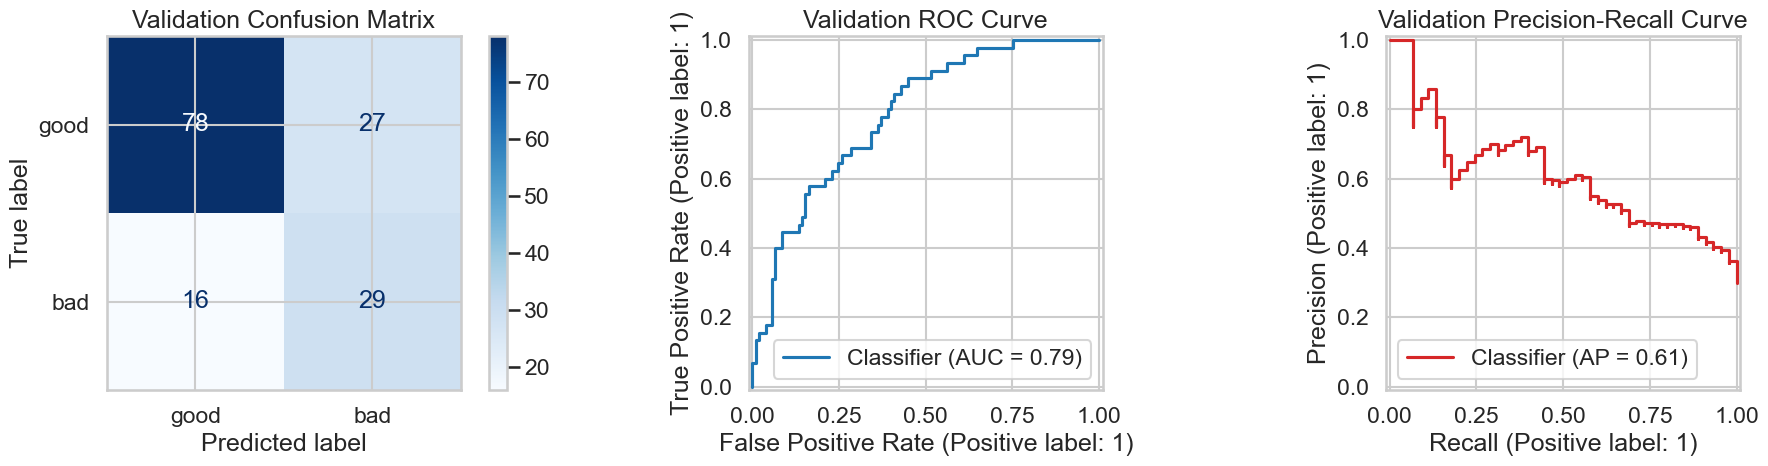

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred,
    display_labels=["good", "bad"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Validation Confusion Matrix")

RocCurveDisplay.from_predictions(y_valid, y_valid_score, ax=axes[1], color="#1f77b4")
axes[1].set_title("Validation ROC Curve")

PrecisionRecallDisplay.from_predictions(y_valid, y_valid_score, ax=axes[2], color="#d62728")
axes[2].set_title("Validation Precision-Recall Curve")

plt.tight_layout()
plt.show()

-16 false negatives are risky because the lender may approve applicants who later default.
-27 false positives are costly because the lender may reject or review good applicants unnecessarily.
-The model is useful, but threshold tuning is needed to balance risk control and approval rate.

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_valid_pred)

cm_df = pd.DataFrame(
    cm,
    index=["actual_good", "actual_bad"],
    columns=["predicted_good", "predicted_bad"]
)

cm_df


,predicted_good,predicted_bad
actual_good,78,27
actual_bad,16,29


In [13]:
cm_df["predicted_good"].sum()


np.int64(94)

In [15]:
import joblib

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

champion_model_path = models_dir / "random_forest_champion_pipeline.joblib"

joblib.dump(best_advanced_pipeline, champion_model_path)

champion_model_path


PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/models/random_forest_champion_pipeline.joblib')

## 11.Advanced Model Results saved

Save model-comparison artifacts for later threshold tuning and explainability.

In [14]:
tables_dir = project_root / "artifacts" / "tables"
profiles_dir = project_root / "artifacts" / "profiles"
tables_dir.mkdir(parents=True, exist_ok=True)
profiles_dir.mkdir(parents=True, exist_ok=True)

advanced_results_path = tables_dir / "advanced_model_validation_results.csv"
comparison_results_path = tables_dir / "model_comparison_validation_results.csv"
summary_path = profiles_dir / "advanced_model_summary.json"

advanced_results_df.to_csv(advanced_results_path, index=False)
model_comparison_df.to_csv(comparison_results_path, index=False)

advanced_summary = {
    "random_state": RANDOM_STATE,
    "models_trained": list(advanced_models.keys()),
    "best_advanced_model": best_advanced_model_name,
    "validation_results": advanced_results_df.to_dict(orient="records"),
    "comparison_results": model_comparison_df.to_dict(orient="records"),
    "note": "Test set remains untouched for final model comparison and business thresholding.",
}

with summary_path.open("w") as f:
    json.dump(advanced_summary, f, indent=2)

advanced_results_path, comparison_results_path, summary_path

(PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/advanced_model_validation_results.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/model_comparison_validation_results.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/profiles/advanced_model_summary.json'))

## 12. Advanced Modeling Decision Summary

The best advanced model in this validation run is **Random Forest**.

Random Forest achieved the strongest overall advanced-model performance, with the highest validation ROC-AUC and PR-AUC among the advanced models. This suggests it has the best overall ability to rank applicants by credit risk in this comparison.

However, model selection should not rely on one metric alone. Logistic Regression remains an important benchmark because it achieved stronger bad-risk recall, while Random Forest is the stronger advanced model overall.

The next stage should focus on explaining the Random Forest model with SHAP and then tuning credit decision thresholds.

Next notebook: `09_explainability_shap.ipynb`.